# Assessment 10: Dimensionality Reduction
**Written By:** Ulrik Favorada, Sam Punzalan, Thom Yutuc

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, silhouette_score
from sklearn.neighbors import NearestNeighbors

np.random.seed(67)

In [2]:
# Install
!pip install umap-learn

In [3]:
# Setup UMAP
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not available. Run: pip install umap-learn")

FEATURES = [
    'Birth Rate', 'Fertility Rate', 'Infant mortality',
    'Life expectancy', 'GDP', 'Unemployment rate',
    'Urban_population', 'Co2-Emissions',
    'Physicians per thousand', 'Density (P/Km2)'
]

## Part 1 — Data Preparation

<span style="color:purple; font-weight:bold;">
<em>Load the dataset, select the 10 features, and drop rows with missing values. Scale the features using StandardScaler. Print how many rows were removed and the final shape of your data.</em>
</span>

In [4]:
# Load Dataset
df = pd.read_csv("world-data-2023.csv")

In [5]:
# Check columns to get selected features
sorted(df.columns)

['Abbreviation',
 'Agricultural Land( %)',
 'Armed Forces size',
 'Birth Rate',
 'CPI',
 'CPI Change (%)',
 'Calling Code',
 'Capital/Major City',
 'Co2-Emissions',
 'Country',
 'Currency-Code',
 'Density\n(P/Km2)',
 'Fertility Rate',
 'Forested Area (%)',
 'GDP',
 'Gasoline Price',
 'Gross primary education enrollment (%)',
 'Gross tertiary education enrollment (%)',
 'Infant mortality',
 'Land Area(Km2)',
 'Largest city',
 'Latitude',
 'Life expectancy',
 'Longitude',
 'Maternal mortality ratio',
 'Minimum wage',
 'Official language',
 'Out of pocket health expenditure',
 'Physicians per thousand',
 'Population',
 'Population: Labor force participation (%)',
 'Tax revenue (%)',
 'Total tax rate',
 'Unemployment rate',
 'Urban_population']

In [6]:
# Remove extra spaces and newlines
df.columns = df.columns.str.strip().str.replace('\n', ' ', regex=True)

In [7]:
# Re-check columns to get selected features
sorted(df.columns)

['Abbreviation',
 'Agricultural Land( %)',
 'Armed Forces size',
 'Birth Rate',
 'CPI',
 'CPI Change (%)',
 'Calling Code',
 'Capital/Major City',
 'Co2-Emissions',
 'Country',
 'Currency-Code',
 'Density (P/Km2)',
 'Fertility Rate',
 'Forested Area (%)',
 'GDP',
 'Gasoline Price',
 'Gross primary education enrollment (%)',
 'Gross tertiary education enrollment (%)',
 'Infant mortality',
 'Land Area(Km2)',
 'Largest city',
 'Latitude',
 'Life expectancy',
 'Longitude',
 'Maternal mortality ratio',
 'Minimum wage',
 'Official language',
 'Out of pocket health expenditure',
 'Physicians per thousand',
 'Population',
 'Population: Labor force participation (%)',
 'Tax revenue (%)',
 'Total tax rate',
 'Unemployment rate',
 'Urban_population']

In [8]:
# Check data types
df.dtypes

Country                                          str
Density (P/Km2)                                  str
Abbreviation                                     str
Agricultural Land( %)                            str
Land Area(Km2)                                   str
Armed Forces size                                str
Birth Rate                                   float64
Calling Code                                 float64
Capital/Major City                               str
Co2-Emissions                                    str
CPI                                              str
CPI Change (%)                                   str
Currency-Code                                    str
Fertility Rate                               float64
Forested Area (%)                                str
Gasoline Price                                   str
GDP                                              str
Gross primary education enrollment (%)           str
Gross tertiary education enrollment (%)       

In [9]:
df['GDP'] = df['GDP'].replace(r'[\$,]', '', regex=True)
df['Unemployment rate'] = df['Unemployment rate'].replace('%', '', regex=True)
df['Urban_population'] = df['Urban_population'].replace(',', '', regex=True)
df['Co2-Emissions'] = df['Co2-Emissions'].replace(',', '', regex=True)
df['Density (P/Km2)'] = df['Density (P/Km2)'].replace(',', '', regex=True)

In [10]:
# Convert str to numeric variables
df[FEATURES] = df[FEATURES].apply(pd.to_numeric, errors='coerce').astype(float)

In [11]:
# Select features based from assessment instructions
df_selected = df[FEATURES]

In [12]:
# Re-check data types
df.dtypes

Country                                          str
Density (P/Km2)                              float64
Abbreviation                                     str
Agricultural Land( %)                            str
Land Area(Km2)                                   str
Armed Forces size                                str
Birth Rate                                   float64
Calling Code                                 float64
Capital/Major City                               str
Co2-Emissions                                float64
CPI                                              str
CPI Change (%)                                   str
Currency-Code                                    str
Fertility Rate                               float64
Forested Area (%)                                str
Gasoline Price                                   str
GDP                                          float64
Gross primary education enrollment (%)           str
Gross tertiary education enrollment (%)       

In [13]:
# Check dataset
before = df_selected.shape
print(df_selected.head())
print(f"\nDataset Size: {before}")

   Birth Rate  Fertility Rate  Infant mortality  Life expectancy  \
0       32.49            4.47              47.9             64.5   
1       11.78            1.62               7.8             78.5   
2       24.28            3.02              20.1             76.7   
3        7.20            1.27               2.7              NaN   
4       40.73            5.52              51.6             60.8   

            GDP  Unemployment rate  Urban_population  Co2-Emissions  \
0  1.910135e+10              11.12         9797273.0         8672.0   
1  1.527808e+10              12.33         1747593.0         4536.0   
2  1.699882e+11              11.70        31510100.0       150006.0   
3  3.154058e+09                NaN           67873.0          469.0   
4  9.463542e+10               6.89        21061025.0        34693.0   

   Physicians per thousand  Density (P/Km2)  
0                     0.28             60.0  
1                     1.20            105.0  
2                     1.72

In [14]:
# Check for missing values
df_selected.isna().sum()

Birth Rate                  6
Fertility Rate              7
Infant mortality            6
Life expectancy             8
GDP                         2
Unemployment rate          19
Urban_population            5
Co2-Emissions               7
Physicians per thousand     7
Density (P/Km2)             0
dtype: int64

In [15]:
# Drop rows with missing values
df_selected = df_selected.dropna()

In [16]:
# Re-check for missing values
df_selected.isna().sum()

Birth Rate                 0
Fertility Rate             0
Infant mortality           0
Life expectancy            0
GDP                        0
Unemployment rate          0
Urban_population           0
Co2-Emissions              0
Physicians per thousand    0
Density (P/Km2)            0
dtype: int64

In [17]:
after = df_selected.shape
print(f"Final Dataset: {df_selected.shape}")
print(f"Rows Dropped: {before[0] - after[0]}")

Final Dataset: (175, 10)
Rows Dropped: 20


In [18]:
# Check dataset types
df_selected.dtypes

Birth Rate                 float64
Fertility Rate             float64
Infant mortality           float64
Life expectancy            float64
GDP                        float64
Unemployment rate          float64
Urban_population           float64
Co2-Emissions              float64
Physicians per thousand    float64
Density (P/Km2)            float64
dtype: object

In [19]:
# Scale Features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_selected)
df_scaled = pd.DataFrame(scaled_data, columns=FEATURES)

In [20]:
# Check if features are scaled
summary = pd.DataFrame({
    'mean': df_scaled.mean(),
    'std': df_scaled.std(ddof=0)
})

print(summary)
print("\nAll features have been scaled because their means are very close to 0 and std is 1 (or similar spread across features)")

                                 mean  std
Birth Rate               1.281515e-16  1.0
Fertility Rate           1.535280e-16  1.0
Infant mortality        -3.375078e-16  1.0
Life expectancy         -1.544162e-15  1.0
GDP                      7.612958e-18  1.0
Unemployment rate        2.740665e-16  1.0
Urban_population         1.015061e-17  1.0
Co2-Emissions           -1.015061e-17  1.0
Physicians per thousand  5.075305e-18  1.0
Density (P/Km2)          2.030122e-17  1.0

All features have been scaled because their means are very close to 0 and std is 1 (or similar spread across features)


<span style="color:purple; font-weight:bold;">
<em>Plot the distribution of each of the 10 features as histograms in a 2×5 grid. Use the original unscaled values.</em>
</span>

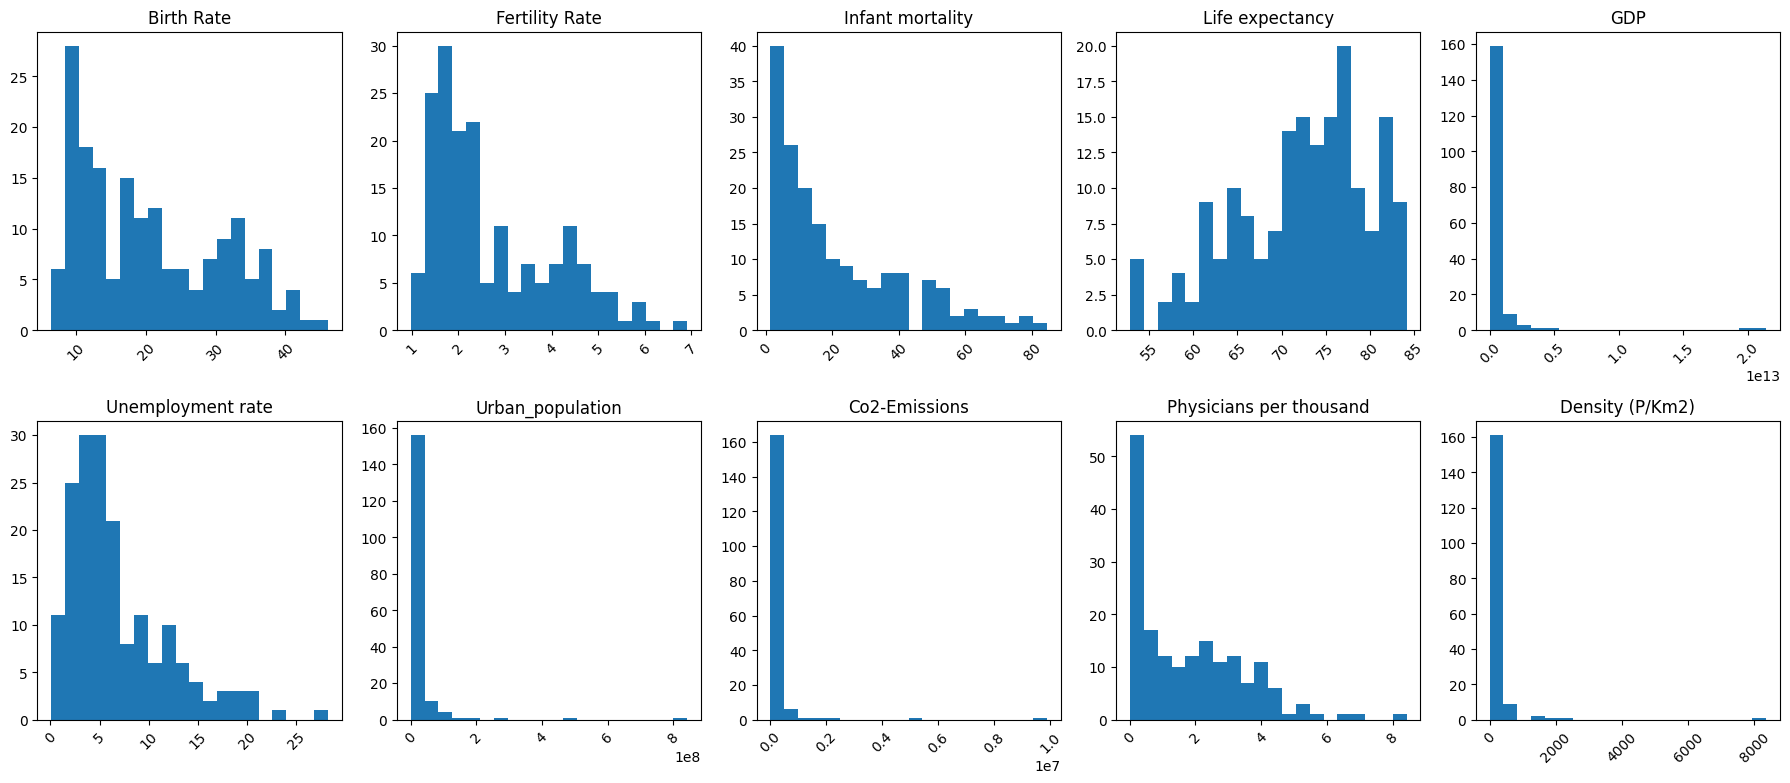

In [21]:
# Create 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(df_selected.columns):
    axes[i].hist(df_selected[col], bins=20)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Q:** <u>*In 3–4 sentences, which features look skewed or have extreme outliers? Why does this matter before running PCA?*</u><br>
**A:** The features with extreme outliers are GDP, Urban_population, Co2-Emissions, Density (P/Km2). This can affect the Principal Component Analysis (PCA) since it is heavily sensitive to outliers as it maximizes variance. With extreme outliers, the variance can get skewed and become inaccurate.

<span style="color:purple; font-weight:bold;">
<em>Make a correlation heatmap of the 10 features. Use the original unscaled values and a diverging colormap.</em>
</span>

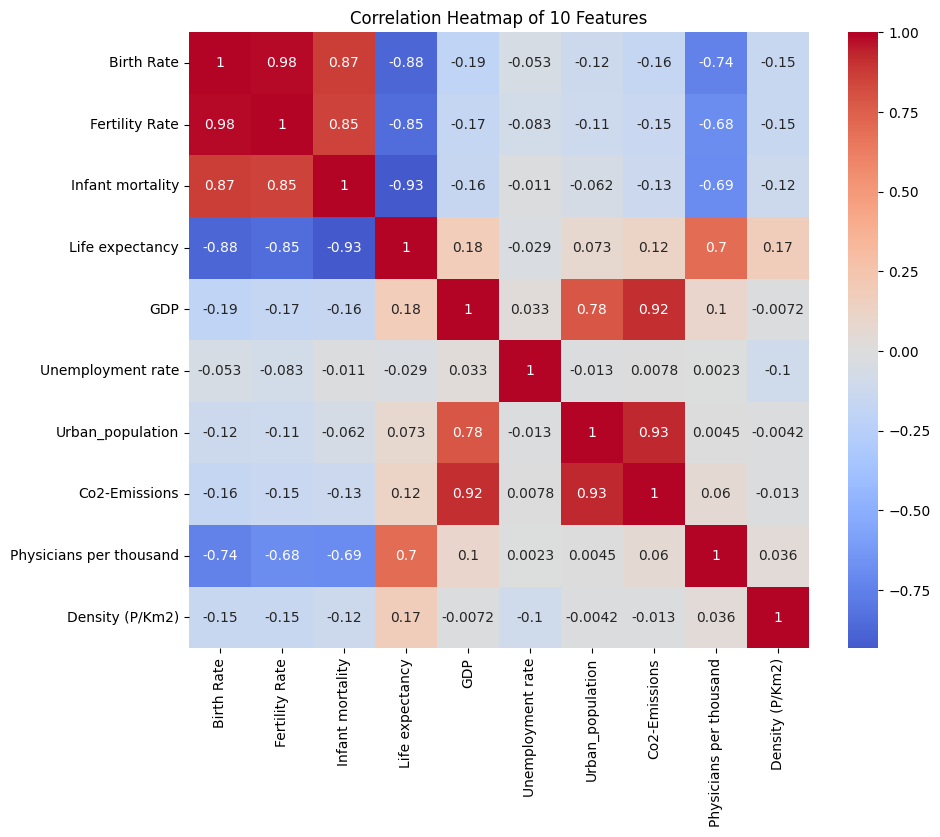

Highly correlated features (±0.7 to ±0.99):

Birth Rate ↔ Fertility Rate: 0.98 (positive)
Birth Rate ↔ Infant mortality: 0.87 (positive)
Birth Rate ↔ Life expectancy: -0.88 (negative)
Birth Rate ↔ Physicians per thousand: -0.74 (negative)
Fertility Rate ↔ Infant mortality: 0.85 (positive)
Fertility Rate ↔ Life expectancy: -0.85 (negative)
Infant mortality ↔ Life expectancy: -0.93 (negative)
GDP ↔ Urban_population: 0.78 (positive)
GDP ↔ Co2-Emissions: 0.92 (positive)
Urban_population ↔ Co2-Emissions: 0.93 (positive)


In [22]:
# Compute correlation matrix
corr = df_selected.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of 10 Features")
plt.show()

high_corr = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]

        # capture both positive and negative strong correlations
        if 0.7 <= abs(val) <= 0.99:
            high_corr.append((corr.columns[i], corr.columns[j], val))

# Print results
print("Highly correlated features (±0.7 to ±0.99):\n")

for a, b, val in high_corr:
    direction = "positive" if val > 0 else "negative"
    print(f"{a} ↔ {b}: {val:.2f} ({direction})")

**Q:** <u>*In 4–5 sentences, name the strongest positive and negative correlations you see and explain what they tell you about how countries develop.*</u><br>
**A:**<br>
The strongest positive correlations are the following:
- Birth Rate ↔ Fertility Rate
- Birth Rate ↔ Infant mortality
- Fertility Rate ↔ Infant mortality
- GDP ↔ Urban_population
- GDP ↔ Co2-Emissions
- Urban_population ↔ Co2-Emissions

The strongest negative correlations are the following:
- Birth Rate ↔ Life expectancy
- Birth Rate ↔ Physicians per thousand
- Fertility Rate ↔ Life expectancy
- Infant mortality ↔ Life expectancy

The country has a problem with child birth since more births lead to more infant deaths and lower life expectancy. With high GDP countries, their urban population and co2 emissions grow since there are more people, more products needs to be produced.

## Part 2 — Principal Component Analysis

<span style="color:purple; font-weight:bold;">
<em>Fit PCA on your scaled data using all 10 components. Make two side-by-side plots: a bar chart of how much variance each component explains, and a cumulative variance curve with lines at 80%, 90%, and 95%. Print a table showing the explained variance and cumulative total for each component.</em>
</span>

In [23]:
# Fit PCA
pca = PCA(n_components=10)
pca_result = pca.fit_transform(df_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

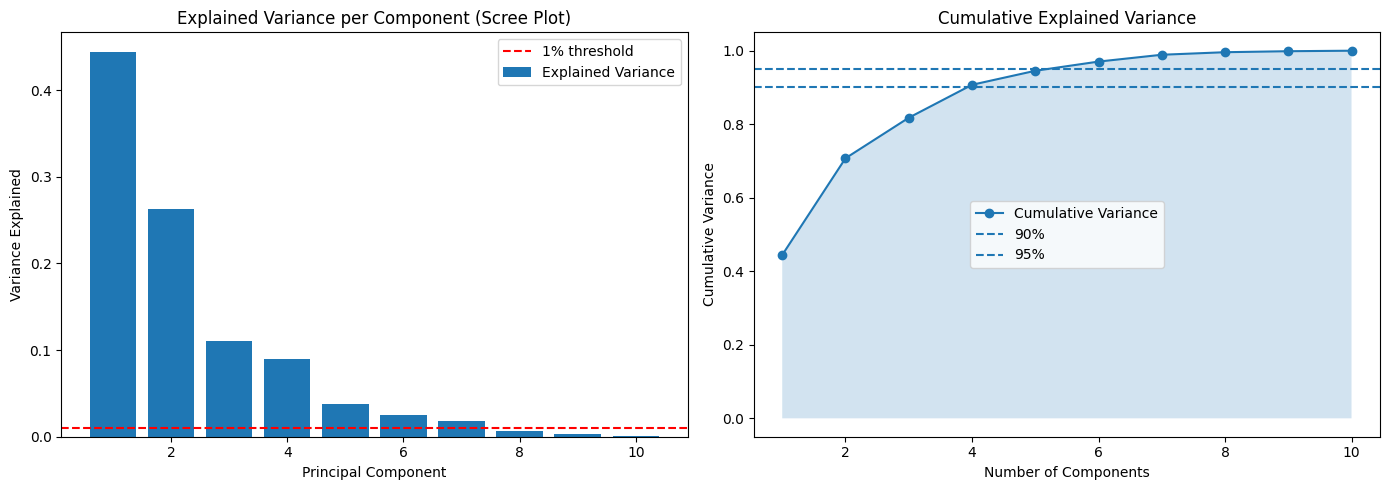

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scree plot ---
axes[0].bar(range(1, 11), explained_var, label="Explained Variance")
axes[0].axhline(0.01, linestyle='--', color='red', label="1% threshold")

axes[0].set_title("Explained Variance per Component (Scree Plot)")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained")
axes[0].legend()

# --- Cumulative variance curve ---
axes[1].plot(range(1, 11), cumulative_var, marker='o', label="Cumulative Variance")

# Threshold lines
axes[1].axhline(0.90, linestyle='--', label="90%")
axes[1].axhline(0.95, linestyle='--', label="95%")

# Shade area under curve
axes[1].fill_between(range(1, 11), cumulative_var, alpha=0.2)

axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

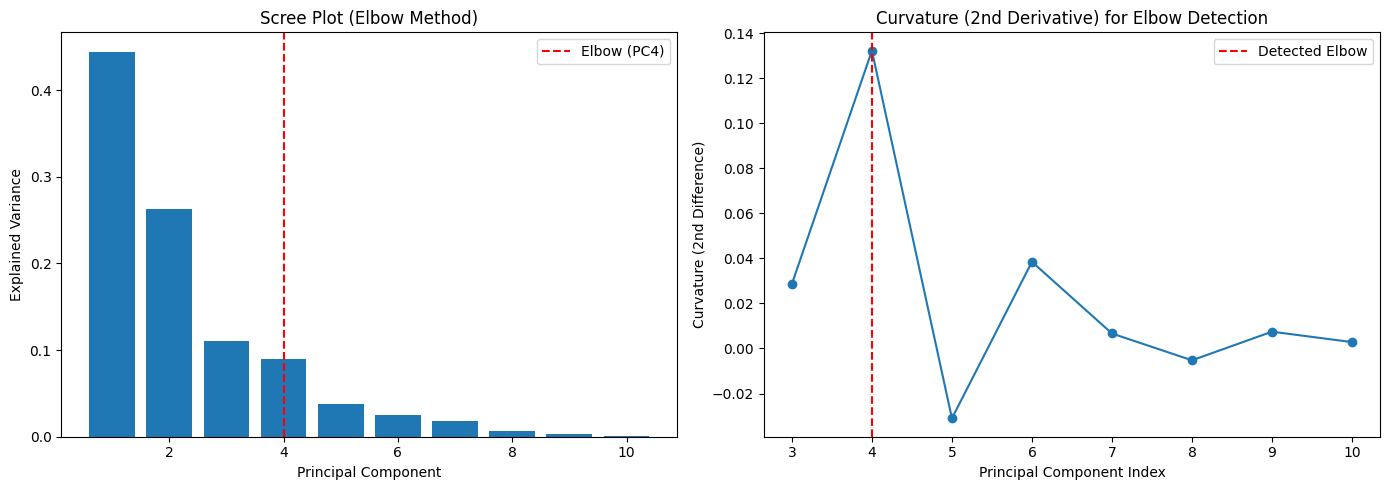

Interpretation:
- Instead of using a fixed 1% heuristic, the elbow method provides a more concrete threshold as we find the elbow point where there is a significant decrease of explained variance.
- The elbow point is identified using the second derivative of the scree plot, which captures the changes of rate decrease of explained variance.
- This point represents where additional principal components begin to yield diminishing returns.


In [25]:
y = explained_var

# 2nd derivative (curvature)
second_diff = np.diff(y, 2)

# elbow index
elbow_point = np.argmin(second_diff) + 2

# Plot 1: Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 11), explained_var)
axes[0].axvline(elbow_point, linestyle='--', color='red',
                label=f"Elbow (PC{elbow_point})")

axes[0].set_title("Scree Plot (Elbow Method)")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance")
axes[0].legend()

# Plot 2: Curvature plot
x_curv = range(3, 11)  # aligns with second_diff output

axes[1].plot(x_curv, second_diff, marker='o')
axes[1].axvline(elbow_point, linestyle='--', color='red',
                label="Detected Elbow")

axes[1].set_title("Curvature (2nd Derivative) for Elbow Detection")
axes[1].set_xlabel("Principal Component Index")
axes[1].set_ylabel("Curvature (2nd Difference)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpretation
print("Interpretation:")
print("- Instead of using a fixed 1% heuristic, the elbow method provides a more concrete threshold as we find the elbow point where there is a significant decrease of explained variance.")
print("- The elbow point is identified using the second derivative of the scree plot, which captures the changes of rate decrease of explained variance.")
print("- This point represents where additional principal components begin to yield diminishing returns.")

In [26]:
pca_table = pd.DataFrame({
    "Component": range(1, 11),
    "Explained Variance": explained_var,
    "Cumulative Variance": cumulative_var
})

print(pca_table)

   Component  Explained Variance  Cumulative Variance
0          1            0.444423             0.444423
1          2            0.262993             0.707416
2          3            0.110219             0.817635
3          4            0.089666             0.907302
4          5            0.038097             0.945399
5          6            0.025015             0.970414
6          7            0.018590             0.989003
7          8            0.006923             0.995926
8          9            0.002719             0.998646
9         10            0.001354             1.000000


**Q:** <u>*How many components do you need to reach 80%, 90%, and 95%? How many will you use going forward and why?*</u><br>
**A:** To reach 80% explained variance, 3 components are needed. For 90% explained variance, 4 components are needed. For 95% explained variance, 5 components are needed. Going forward, we will use 4 principal components because they explain around 90% of the variance while still achieving meaningful dimensionality reduction. This choice is also supported by the elbow method, which indicates diminishing returns after the fourth component.

<span style="color:purple; font-weight:bold;">
<em>Fit PCA with 2 components. Make a scatter plot of the countries on PC1 vs PC2. Color each country by its development level based on GDP quartiles — label them Low, Lower-Middle, Upper-Middle, and High. Add arrows showing how each of the 10 features points in PC1–PC2 space (biplot). Print a table of the feature loadings sorted by PC1.</em>
</span>

In [27]:
# Use index-based alignment to get countries and gdp to align
countries = df.loc[df_selected.index, "Country"]

# GDP (original dataset)
gdp = df.loc[df_selected.index, "GDP"]

gdp_q = pd.qcut(gdp, 4, labels=["Low", "Lower-Middle", "Upper-Middle", "High"])

In [28]:
# Fit PCA on PC1 and PC2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

loadings = pca.components_.T

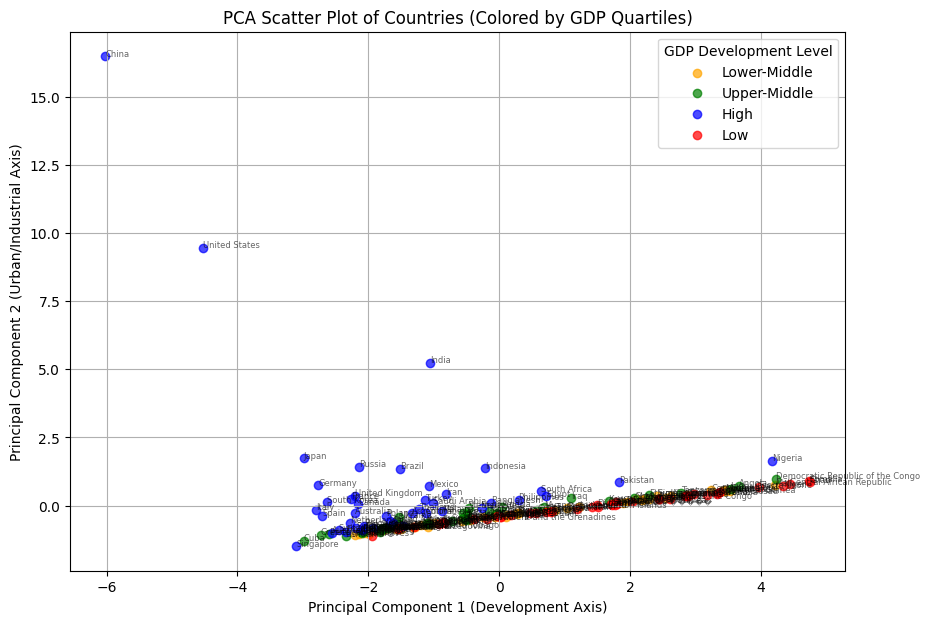

In [29]:
# Scatter Plot
plt.figure(figsize=(10, 7))

colors = {
    "Low": "red",
    "Lower-Middle": "orange",
    "Upper-Middle": "green",
    "High": "blue"
}

for level in gdp_q.unique():
    idx = gdp_q == level

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=level,
        alpha=0.7,
        color=colors[level]
    )

    # country labels
    for i in np.where(idx)[0]:
        plt.text(
            X_pca[i, 0],
            X_pca[i, 1],
            countries.iloc[i],
            fontsize=6,
            alpha=0.6
        )

plt.xlabel("Principal Component 1 (Development Axis)")
plt.ylabel("Principal Component 2 (Urban/Industrial Axis)")
plt.title("PCA Scatter Plot of Countries (Colored by GDP Quartiles)")
plt.legend(title="GDP Development Level")
plt.grid(True)

plt.show()

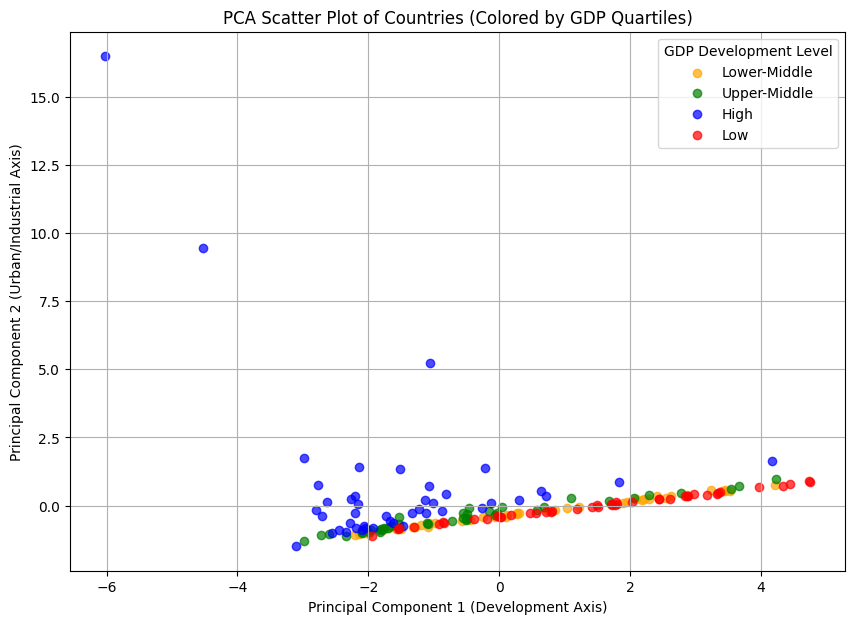

In [30]:
# Scatter Plot
plt.figure(figsize=(10, 7))

colors = {
    "Low": "red",
    "Lower-Middle": "orange",
    "Upper-Middle": "green",
    "High": "blue"
}

for level in gdp_q.unique():
    idx = gdp_q == level

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=level,
        alpha=0.7,
        color=colors[level]
    )

plt.xlabel("Principal Component 1 (Development Axis)")
plt.ylabel("Principal Component 2 (Urban/Industrial Axis)")
plt.title("PCA Scatter Plot of Countries (Colored by GDP Quartiles)")
plt.legend(title="GDP Development Level")
plt.grid(True)

plt.show()

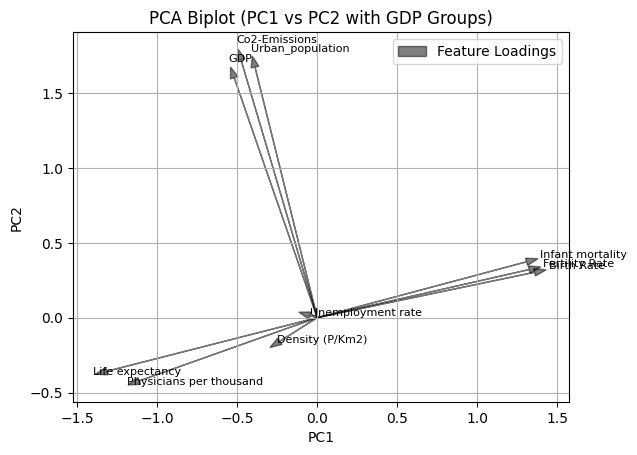

In [31]:
for i, feature in enumerate(FEATURES):
    plt.arrow(
        0, 0,
        loadings[i, 0] * 3,
        loadings[i, 1] * 3,
        color="black",
        alpha=0.5,
        head_width=0.05,
        label="Feature Loadings" if i == 0 else ""
    )
    plt.text(
        loadings[i, 0] * 3.2,
        loadings[i, 1] * 3.2,
        feature,
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot (PC1 vs PC2 with GDP Groups)")
plt.legend()
plt.grid()
plt.show()

In [32]:
# Feature loading table
loading_df = pd.DataFrame(
    loadings,
    columns=["PC1", "PC2"],
    index=FEATURES
)

# SORT BY PC1
pc1_sorted = loading_df["PC1"].sort_values(ascending=False)

print("\n===== Sorted by PC1 =====")
print(pc1_sorted)

# SORT BY PC2
pc2_sorted = loading_df["PC2"].sort_values(ascending=False)

print("\n===== Sorted by PC2 =====")
print(pc2_sorted)


===== Sorted by PC1 =====
Birth Rate                 0.453211
Fertility Rate             0.442032
Infant mortality           0.436516
Unemployment rate         -0.014727
Density (P/Km2)           -0.078046
Urban_population          -0.129778
Co2-Emissions             -0.158997
GDP                       -0.173042
Physicians per thousand   -0.371266
Life expectancy           -0.438689
Name: PC1, dtype: float64

===== Sorted by PC2 =====
Co2-Emissions              0.574188
Urban_population           0.557744
GDP                        0.534056
Infant mortality           0.124375
Fertility Rate             0.107055
Birth Rate                 0.101049
Unemployment rate          0.004690
Density (P/Km2)           -0.052659
Life expectancy           -0.119323
Physicians per thousand   -0.140855
Name: PC2, dtype: float64


In [33]:
# Variance (average squared spread around mean) for each gdp development level
cluster_var = {}

for level in gdp_q.unique():
    idx = gdp_q == level
    cluster_var[level] = np.var(X_pca[idx])

print(pd.Series(cluster_var).sort_values())

Upper-Middle    1.752515
Lower-Middle    2.098277
Low             2.299545
High            6.991980
dtype: float64


In [34]:
# Standard Deviation (typical spread around mean) for each gdp development level
cluster_spread = {}

for level in gdp_q.unique():
    idx = gdp_q == level
    cluster_points = X_pca[idx]

    # measure spread in PCA space
    spread = np.mean(np.std(cluster_points, axis=0))

    cluster_spread[level] = spread

print(pd.Series(cluster_spread).sort_values())

Low             1.143036
Upper-Middle    1.167909
Lower-Middle    1.213137
High            2.285638
dtype: float64


**Q1:** <u>*What does PC1 seem to represent based on which features load highest on it?*</u><br>
**A1:** PC1 seems to represent a country's development. If a country has a high PC1, they have a higher birth rate, fertility rate, infant mortality. If a country has a lower PC1 have a higher GDP, Physicians per thousand, Life expectancy.

**Q2:** <u>*What does PC2 seem to capture that PC1 does not?*</u><br>
**A2:** PC2 seems to represent a industrial development. If a country has a high PC2, they have a higher Co2-Emissions, Urban_population, GDP. If a country has a lower PC2 have a higher Physicians per thousand, Life expectancy, Density (P/Km2).

**Q3:** <u>*Which development group clusters most tightly together? Which spreads out the most?*</u><br>
**A3:** The development group cluster that is most tightly together is Low and the one that spreads out the most is high.

<span style="color:purple; font-weight:bold;">
<em>For k = 1, 2, 3, 4, 6, 8, and 10 components, reconstruct the data from PCA and compute the mean squared error (MSE) between the reconstruction and the original scaled data. Plot MSE vs number of components. For k = 2, find the 5 countries with the highest MSE and the 5 with the lowest. Print both lists.</em>
</span>

In [35]:
# k values
k_values = [1, 2, 3, 4, 6, 8, 10]
mse_list = []

# store results for k=2 analysis
recon_k2 = None

In [36]:
# PCA reconstruction loop
for k in k_values:
    pca = PCA(n_components=k)
    
    X_pca_k = pca.fit_transform(df_scaled)
    X_reconstructed = pca.inverse_transform(X_pca_k)
    
    mse = mean_squared_error(df_scaled, X_reconstructed)
    mse_list.append(mse)
    
    if k == 2:
        recon_k2 = X_reconstructed

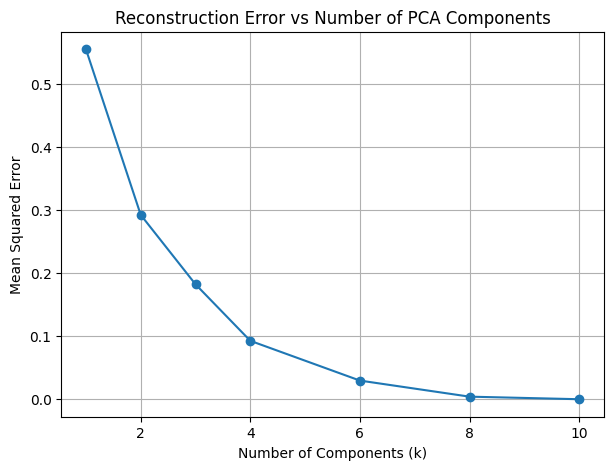

In [37]:
# MSE plot
plt.figure(figsize=(7, 5))
plt.plot(k_values, mse_list, marker='o')
plt.title("Reconstruction Error vs Number of PCA Components")
plt.xlabel("Number of Components (k)")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

In [38]:
# k = 2 analysis
# compute per-country reconstruction error
errors = np.mean((df_scaled.values - recon_k2) ** 2, axis=1)

error_df = pd.DataFrame({
    "Country": countries.values,
    "MSE": errors
})

# highest error = worst reconstructed
top_5 = error_df.sort_values(by="MSE", ascending=False).head(5)

# lowest error = best reconstructed
bottom_5 = error_df.sort_values(by="MSE").head(5)

print("\n===== TOP 5 HIGHEST MSE (Worst Reconstruction) =====")
print(top_5)

print("\n===== TOP 5 LOWEST MSE (Best Reconstruction) =====")
print(bottom_5)


===== TOP 5 HIGHEST MSE (Worst Reconstruction) =====
           Country        MSE
138      Singapore  13.996706
166  United States   2.125179
143   South Africa   1.901195
88         Lesotho   1.472875
71           India   1.265305

===== TOP 5 LOWEST MSE (Best Reconstruction) =====
                Country       MSE
14              Belgium  0.018254
46   Dominican Republic  0.020506
39              Croatia  0.023651
92           Luxembourg  0.024848
139            Slovakia  0.028150


**Q:** <u>*In 3–4 sentences, why do you think certain countries have high reconstruction error? What does that tell you about those countries?*</u><br>
**A:** Certain countries have high reconstruction error because their patterns are not well captured by the first few principal components. This means they do not follow the dominant global trends of the other features in the PCA. As a result, reducing them to fewer dimensions causes a large loss of information when reconstructing the original data. These countries likely have more unique combinations of features compared to the general global structure.

## Part 3 — t-SNE and UMAP

<span style="color:purple; font-weight:bold;">
<em>Run t-SNE at four perplexity values: 5, 15, 30, and 50. Use max_iter=1000, random_state=42, and init='pca'. Plot all four results in a 2×2 grid, colored by development level. Make a small summary table with columns: perplexity, how well the clusters separated (Poor / Fair / Good / Excellent), and one observation per run.</em>
</span>

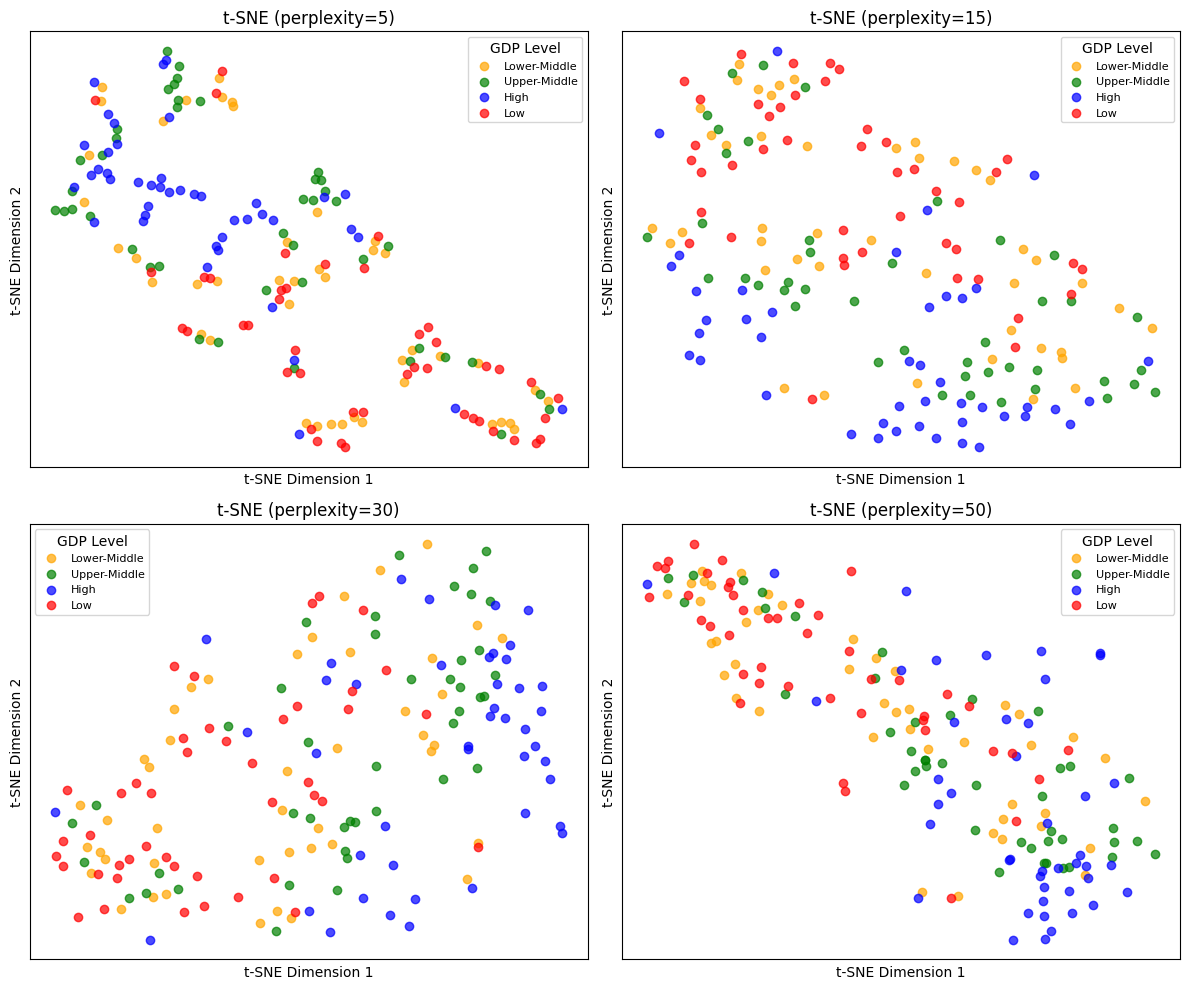

In [39]:
perplexities = [5, 15, 30, 50]

summary = []

plt.figure(figsize=(12, 10))

for i, perp in enumerate(perplexities):
    
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=1000,
        random_state=42,
        init='pca'
    )
    
    X_tsne = tsne.fit_transform(df_scaled)

    plt.subplot(2, 2, i + 1)  # FIXED: 2x2 grid for 4 plots

    colors = {
        "Low": "red",
        "Lower-Middle": "orange",
        "Upper-Middle": "green",
        "High": "blue"
    }

    for level in gdp_q.unique():
        idx = gdp_q == level

        plt.scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=level,
            alpha=0.7,
            color=colors[level]
        )

    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.title(f"t-SNE (perplexity={perp})")

    plt.legend(title="GDP Level", fontsize=8)
    plt.xticks([])
    plt.yticks([])

    # heuristic score
    cluster_spread = np.std(X_tsne, axis=0).mean()

    if cluster_spread < 5:
        quality = "Poor"
    elif cluster_spread < 8:
        quality = "Fair"
    elif cluster_spread < 12:
        quality = "Good"
    else:
        quality = "Excellent"

    observation = ""

    if perp == 5:
        observation = "Clusters are very tight and forms line like shapes."
    elif perp == 15:
        observation = "Clusters start to separate."
    elif perp == 30:
        observation = "Clusters are more separated (looks like a mirrored 15)."
    elif perp == 50:
        observation = "Cluster starting to overlap and possibly merge."

    summary.append([perp, quality, observation])

plt.tight_layout()
plt.show()

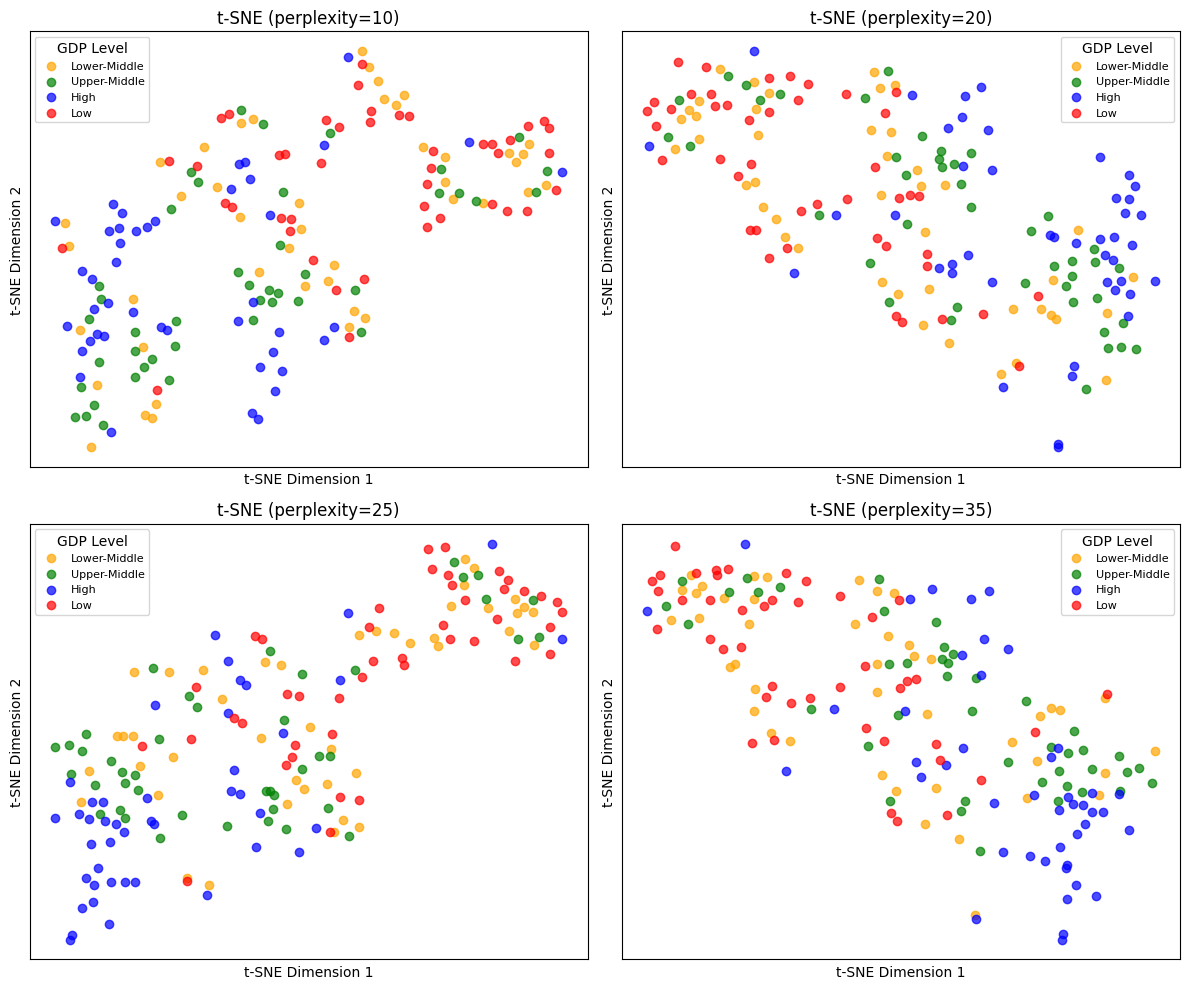

In [40]:
# Extra Test
perplexities = [10, 20, 25, 35]

plt.figure(figsize=(12, 10))

for i, perp in enumerate(perplexities):
    
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=1000,
        random_state=42,
        init='pca'
    )
    
    X_tsne = tsne.fit_transform(df_scaled)

    plt.subplot(2, 2, i + 1)  # FIXED: 2x2 grid for 4 plots

    colors = {
        "Low": "red",
        "Lower-Middle": "orange",
        "Upper-Middle": "green",
        "High": "blue"
    }

    for level in gdp_q.unique():
        idx = gdp_q == level

        plt.scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=level,
            alpha=0.7,
            color=colors[level]
        )

    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.title(f"t-SNE (perplexity={perp})")

    plt.legend(title="GDP Level", fontsize=8)
    plt.xticks([])
    plt.yticks([])

    # heuristic score
    cluster_spread = np.std(X_tsne, axis=0).mean()

    if cluster_spread < 5:
        quality = "Poor"
    elif cluster_spread < 8:
        quality = "Fair"
    elif cluster_spread < 12:
        quality = "Good"
    else:
        quality = "Excellent"

    observation = ""

    if perp == 5:
        observation = "Highly fragmented clusters; strong local structure."
    elif perp == 15:
        observation = "Best cluster separation and structure balance."
    elif perp == 30:
        observation = "Well-separated clusters with good global structure."
    elif perp == 50:
        observation = "Over-smoothed; clusters begin to merge."

plt.tight_layout()
plt.show()

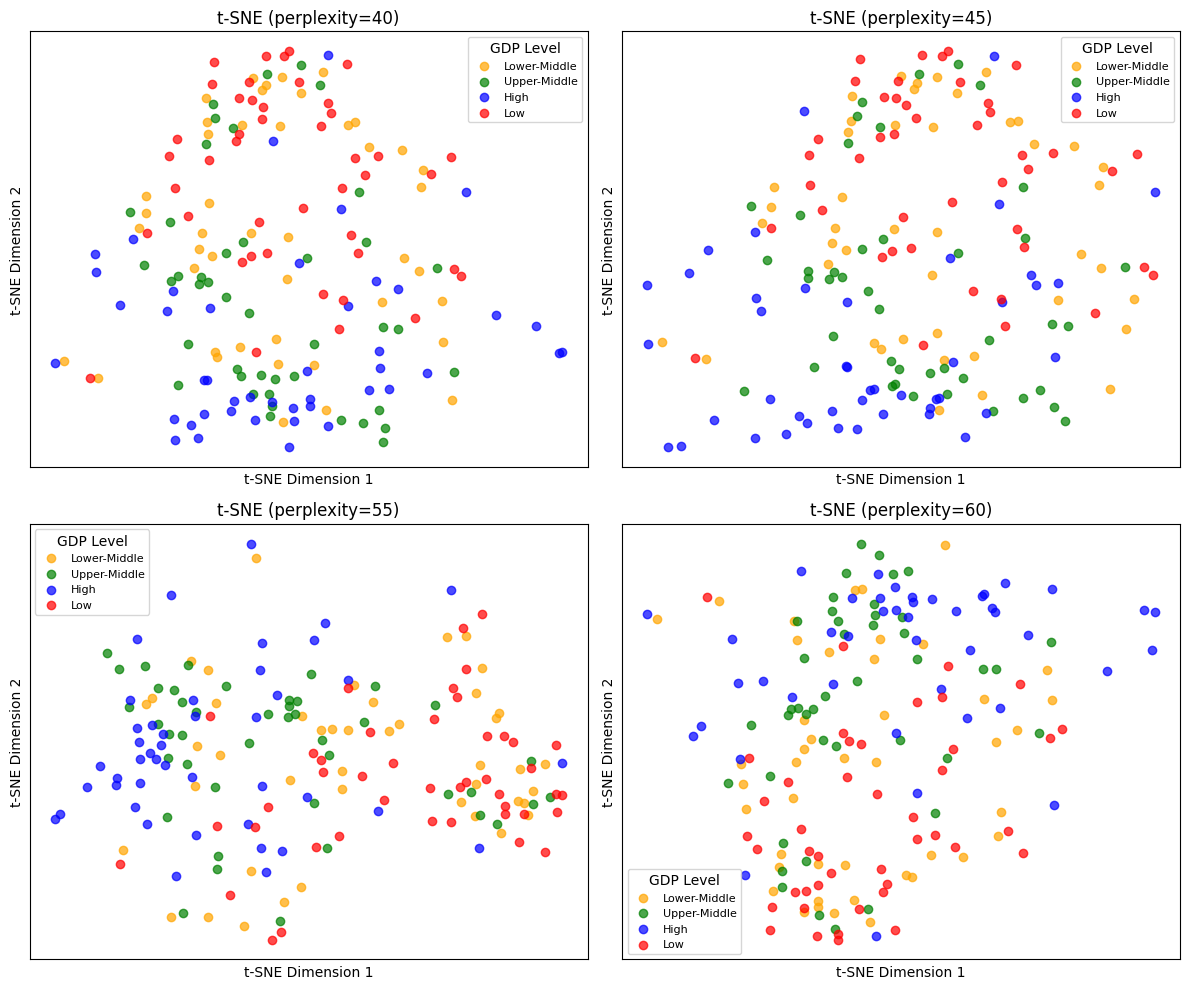

In [41]:
# Extra Test
perplexities = [40, 45, 55, 60]

plt.figure(figsize=(12, 10))

for i, perp in enumerate(perplexities):
    
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=1000,
        random_state=42,
        init='pca'
    )
    
    X_tsne = tsne.fit_transform(df_scaled)

    plt.subplot(2, 2, i + 1)  # FIXED: 2x2 grid for 4 plots

    colors = {
        "Low": "red",
        "Lower-Middle": "orange",
        "Upper-Middle": "green",
        "High": "blue"
    }

    for level in gdp_q.unique():
        idx = gdp_q == level

        plt.scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=level,
            alpha=0.7,
            color=colors[level]
        )

    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.title(f"t-SNE (perplexity={perp})")

    plt.legend(title="GDP Level", fontsize=8)
    plt.xticks([])
    plt.yticks([])

    # heuristic score
    cluster_spread = np.std(X_tsne, axis=0).mean()

    if cluster_spread < 5:
        quality = "Poor"
    elif cluster_spread < 8:
        quality = "Fair"
    elif cluster_spread < 12:
        quality = "Good"
    else:
        quality = "Excellent"

    observation = ""

    if perp == 5:
        observation = "Highly fragmented clusters; strong local structure."
    elif perp == 15:
        observation = "Best cluster separation and structure balance."
    elif perp == 30:
        observation = "Well-separated clusters with good global structure."
    elif perp == 50:
        observation = "Over-smoothed; clusters begin to merge."

plt.tight_layout()
plt.show()

In [42]:
# allow full text display
pd.set_option('display.max_colwidth', None)

# SUMMARY TABLE
summary_df = pd.DataFrame(
    summary,
    columns=["Perplexity", "Cluster Separation", "Observation"]
)

print("\n===== t-SNE SUMMARY TABLE =====")
print(summary_df)


===== t-SNE SUMMARY TABLE =====
   Perplexity Cluster Separation  \
0           5          Excellent   
1          15          Excellent   
2          30               Fair   
3          50               Poor   

                                               Observation  
0      Clusters are very tight and forms line like shapes.  
1                              Clusters start to separate.  
2  Clusters are more separated (looks like a mirrored 15).  
3          Cluster starting to overlap and possibly merge.  


In [43]:
# Hard to tell using graphs so lets try using separation scores
perplexities = list(range(5, 65, 5))  # 5,10,...,60

results = []

for perp in perplexities:
    
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=1000,
        random_state=42,
        init='pca'
    )
    
    X_tsne = tsne.fit_transform(df_scaled)

    # compute cluster centroids
    centroids = []

    for level in gdp_q.unique():
        idx = gdp_q == level
        centroid = X_tsne[idx].mean(axis=0)
        centroids.append(centroid)

    centroids = np.array(centroids)

    # separation score
    # (mean pairwise distance between centroids)
    dists = []

    for i in range(len(centroids)):
        for j in range(i + 1, len(centroids)):
            dists.append(np.linalg.norm(centroids[i] - centroids[j]))

    separation_score = np.mean(dists)

    results.append([perp, separation_score])

# create table
separation_df = pd.DataFrame(
    results,
    columns=["Perplexity", "Separation Score"]
)

print(separation_df)

best_row = separation_df.loc[separation_df["Separation Score"].idxmax()]

print("\nBest Perplexity (based on Separation Score):")
print(best_row)

    Perplexity  Separation Score
0            5         22.879683
1           10         18.831930
2           15         14.968122
3           20          9.527577
4           25          7.983297
5           30          6.406342
6           35          5.217230
7           40          4.426605
8           45          4.121077
9           50          3.542285
10          55          3.250179
11          60          2.905230

Best Perplexity (based on Separation Score):
Perplexity           5.000000
Separation Score    22.879683
Name: 0, dtype: float64


In [44]:
# Lets try silhouette score
perplexities = list(range(5, 65, 5))

results = []

for perp in perplexities:
    
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=1000,
        random_state=42,
        init='pca'
    )
    
    X_tsne = tsne.fit_transform(df_scaled)

    # silhouette uses labels (GDP groups)
    score = silhouette_score(X_tsne, gdp_q)

    results.append([perp, score])

sil_df = pd.DataFrame(results, columns=["Perplexity", "Silhouette Score"])

print(sil_df)

best_perp = sil_df.loc[sil_df["Silhouette Score"].idxmax()]
print(best_perp)

    Perplexity  Silhouette Score
0            5         -0.059319
1           10         -0.068480
2           15         -0.049127
3           20         -0.059656
4           25         -0.053169
5           30         -0.053782
6           35         -0.058704
7           40         -0.067709
8           45         -0.056606
9           50         -0.074171
10          55         -0.071672
11          60         -0.064615
Perplexity          15.000000
Silhouette Score    -0.049127
Name: 2, dtype: float64


In [45]:
# Lets try K-NN Preservation
perplexities = list(range(5, 65, 5))
k = 10  # number of neighbors to check

results = []

# fit NN on ORIGINAL data
nn_orig = NearestNeighbors(n_neighbors=k+1).fit(df_scaled)
orig_neighbors = nn_orig.kneighbors(return_distance=False)

for perp in perplexities:
    
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=1000,
        random_state=42,
        init='pca'
    )
    
    X_tsne = tsne.fit_transform(df_scaled)

    # NN on t-SNE space
    nn_tsne = NearestNeighbors(n_neighbors=k+1).fit(X_tsne)
    tsne_neighbors = nn_tsne.kneighbors(return_distance=False)

    # compute preservation
    preservation_scores = []

    for i in range(len(df_scaled)):
        orig_set = set(orig_neighbors[i][1:])   # exclude self
        tsne_set = set(tsne_neighbors[i][1:])   # exclude self

        overlap = len(orig_set.intersection(tsne_set))
        preservation_scores.append(overlap / k)

    avg_score = np.mean(preservation_scores)

    results.append([perp, avg_score])

knn_df = pd.DataFrame(results, columns=["Perplexity", "kNN Preservation Score"])

print(knn_df)

best_row = knn_df.loc[knn_df["kNN Preservation Score"].idxmax()]

print("\nBest Perplexity (based on k-NN Preservation):")
print(best_row)

    Perplexity  kNN Preservation Score
0            5                0.548571
1           10                0.577143
2           15                0.604000
3           20                0.607429
4           25                0.604571
5           30                0.635429
6           35                0.618286
7           40                0.616000
8           45                0.613714
9           50                0.579429
10          55                0.593143
11          60                0.601143

Best Perplexity (based on k-NN Preservation):
Perplexity                30.000000
kNN Preservation Score     0.635429
Name: 5, dtype: float64


Explanations:

- Its quite hard to see the separation through the scatter plot so lets try metrics
- **separation score** - Measures how far apart the centers (centroids) of each class are in the t-SNE space (are groups far apart)
- **silhouette score** - Measures how well points fit within their assigned group compared to other groups (do points belong in the right group)
- **k-nn preservation** - Checks whether nearest neighbors stay the same after projection (did t-SNE keep friendships intact)

In this case, **separation score** is not reliable since there is a decreasing pattern as perplexity increases (probably due to it being GDP related). **Silhouette score** doesn't really help since it just checks if they belong to the group and all perplexities are negative. **K-NN preservation** seems more reliable because the scores are varying and what it does is check if t-SNE kept each point’s nearest neighbors the same after reducing dimensions.

**Q:** <u>*Which perplexity gave the clearest result for this dataset? Why — what does perplexity actually control?*</u><br>
**A:** The perplexity that gave the clearest result is 30. Perplexity controls the effective number of neighbors that each point considers when constructing the t-SNE embedding.

P.S. If I use graph only with no metrics best is 15 but lets follow metrics.

<span style="color:purple; font-weight:bold;">
<em>Run UMAP at three n_neighbors values (5, 15, 50) with min_dist=0.1. Plot side by side. Then run UMAP at n_neighbors=15 with three min_dist values (0.0, 0.1, 0.5). Plot side by side. You will have 6 plots total across two rows.</em>
</span>

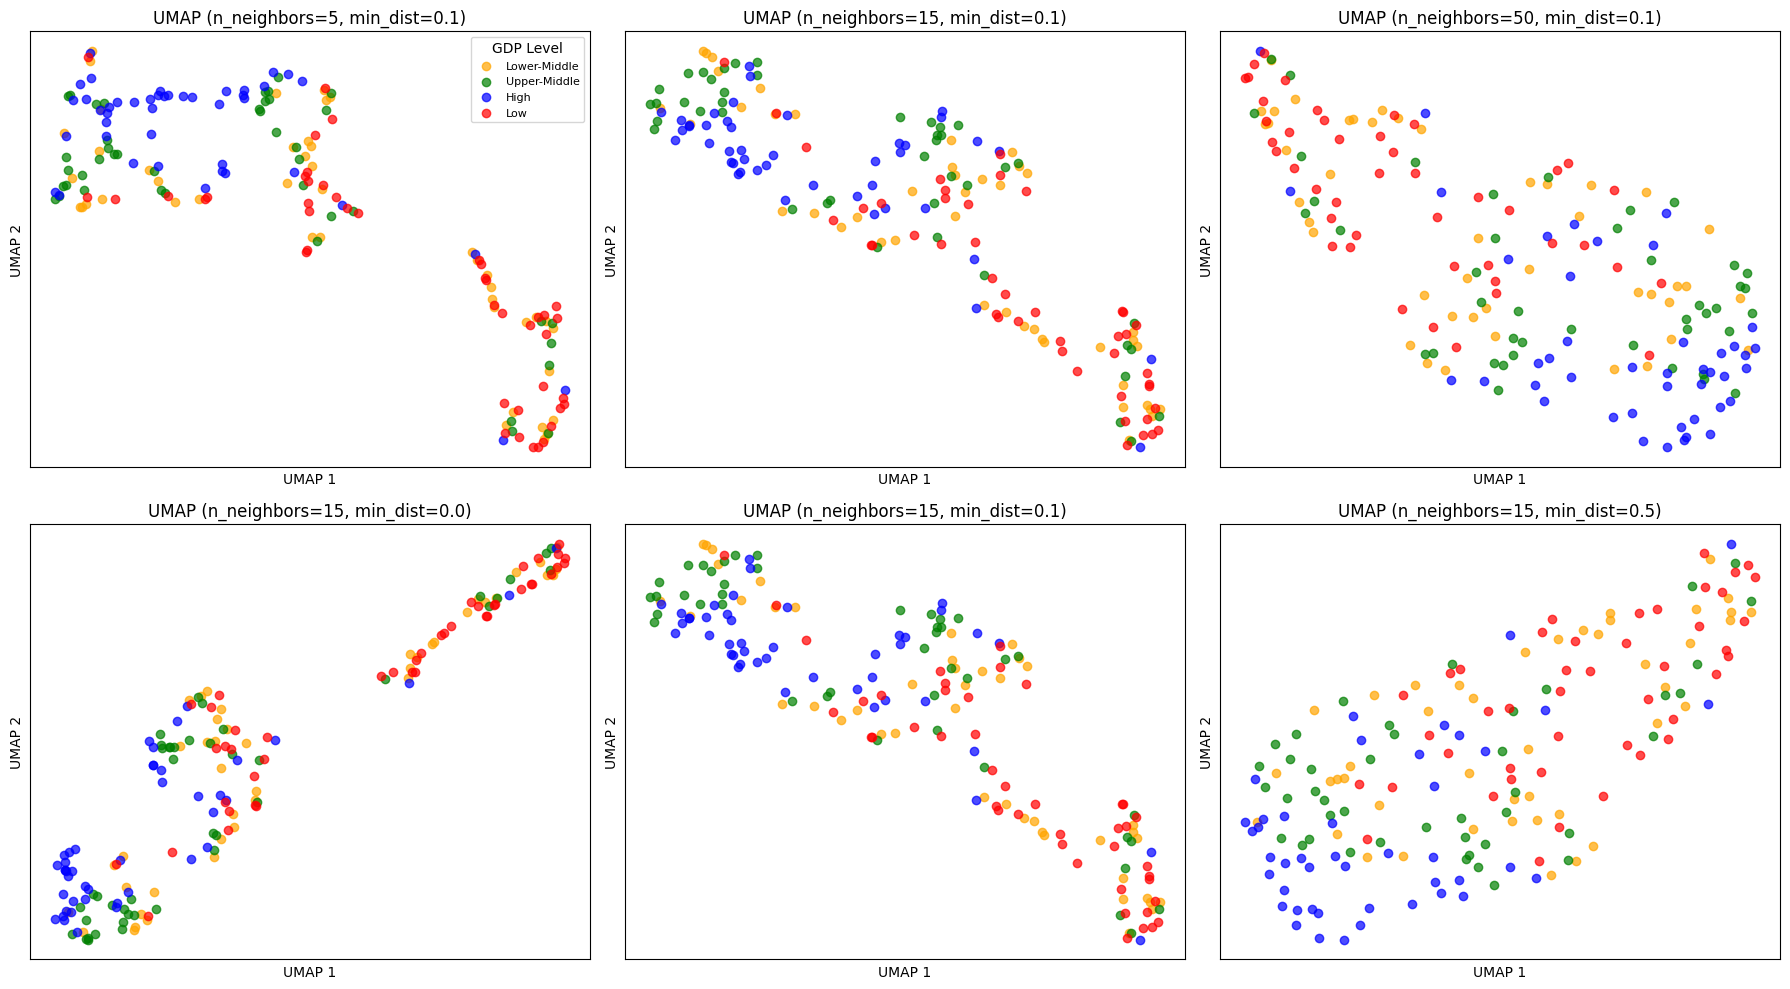

In [46]:
# SETTINGS
neighbors_list = [5, 15, 50]
min_dist_list = [0.0, 0.1, 0.5]

colors = {
    "Low": "red",
    "Lower-Middle": "orange",
    "Upper-Middle": "green",
    "High": "blue"
}

plt.figure(figsize=(18, 10))

# ROW 1: VARY n_neighbors
for i, n in enumerate(neighbors_list):
    
    reducer = umap.UMAP(
        n_neighbors=n,
        min_dist=0.1,
        random_state=42
    )
    
    X_umap = reducer.fit_transform(df_scaled)

    plt.subplot(2, 3, i + 1)

    for level in gdp_q.unique():
        idx = gdp_q == level

        plt.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            color=colors[level],
            label=level,
            alpha=0.7
        )

    plt.title(f"UMAP (n_neighbors={n}, min_dist=0.1)")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.xticks([])
    plt.yticks([])

    if i == 0:  # show legend only once
        plt.legend(title="GDP Level", fontsize=8)

# ROW 2: VARY min_dist
for i, md in enumerate(min_dist_list):
    
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=md,
        random_state=42
    )
    
    X_umap = reducer.fit_transform(df_scaled)

    plt.subplot(2, 3, i + 4)

    for level in gdp_q.unique():
        idx = gdp_q == level

        plt.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            color=colors[level],
            label=level,
            alpha=0.7
        )

    plt.title(f"UMAP (n_neighbors=15, min_dist={md})")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

In [47]:
# SETTINGS
neighbors_list = [5, 15, 50]
min_dist_list = [0.0, 0.1, 0.5]

k = 10  # number of neighbors
results = []

# ORIGINAL nearest neighbors (fixed baseline)
nn_orig = NearestNeighbors(n_neighbors=k+1).fit(df_scaled)
orig_neighbors = nn_orig.kneighbors(return_distance=False)

for n in neighbors_list:
    for md in min_dist_list:

        reducer = umap.UMAP(
            n_neighbors=n,
            min_dist=md,
            random_state=42
        )

        X_umap = reducer.fit_transform(df_scaled)

        # neighbors in UMAP space
        nn_umap = NearestNeighbors(n_neighbors=k+1).fit(X_umap)
        umap_neighbors = nn_umap.kneighbors(return_distance=False)

        # kNN preservation score
        scores = []

        for i in range(len(df_scaled)):
            orig_set = set(orig_neighbors[i][1:])   # exclude self
            umap_set = set(umap_neighbors[i][1:])   # exclude self

            overlap = len(orig_set.intersection(umap_set))
            scores.append(overlap / k)

        avg_score = np.mean(scores)

        results.append([n, md, avg_score])

# RESULTS TABLE
knn_umap_df = pd.DataFrame(
    results,
    columns=["n_neighbors", "min_dist", "kNN Preservation Score"]
)

print("\n===== UMAP k-NN PRESERVATION =====")
print(knn_umap_df.sort_values(by="kNN Preservation Score", ascending=False))


===== UMAP k-NN PRESERVATION =====
   n_neighbors  min_dist  kNN Preservation Score
5           15       0.5                0.570857
2            5       0.5                0.558857
4           15       0.1                0.552000
3           15       0.0                0.552000
8           50       0.5                0.545143
7           50       0.1                0.544571
1            5       0.1                0.525714
6           50       0.0                0.521714
0            5       0.0                0.520571


**Q:** <u>*In 4–5 sentences, what do n_neighbors and min_dist each control? How did changing them change your plots?*</u><br>
**A:** n_neighbors controls how much of the data’s structure is considered when building the embedding, balancing local and global relationships. min_dist controls how closely points are allowed to pack together in the low-dimensional space. In the plots, increasing n_neighbors made clusters less compact and more whole than separated, while increasing min_dist made clusters less dense and more spread out.

<span style="color:purple; font-weight:bold;">
<em>Take your best t-SNE result and your best UMAP result (n_neighbors=15, min_dist=0.1). Plot them side by side and label these 15 countries directly on each plot:

United States, China, India, Brazil, Germany, Nigeria, Ethiopia, Japan, Russian Federation, South Africa, Indonesia, Mexico, Bangladesh, Norway, Haiti

If any of these names are not in your dataset, note which ones are missing.</em>
</span>

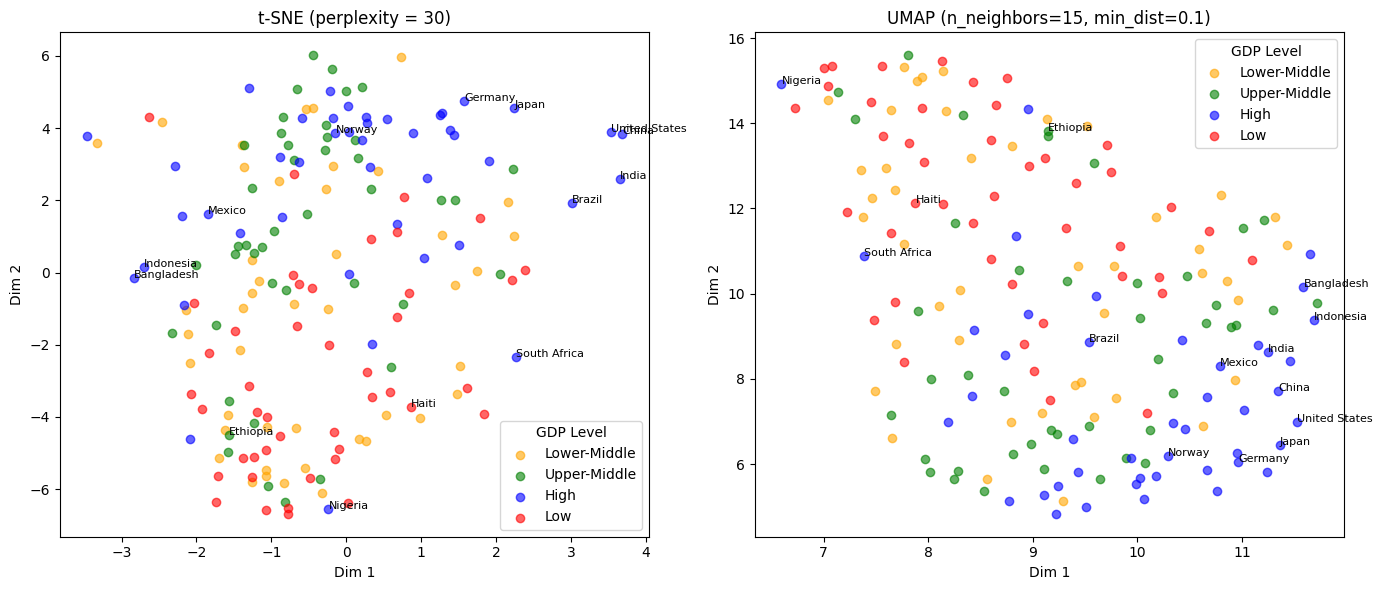


Missing countries:
['Russian Federation']


In [48]:
# TARGET COUNTRIES
target_countries = [
    "United States", "China", "India", "Brazil", "Germany",
    "Nigeria", "Ethiopia", "Japan", "Russian Federation",
    "South Africa", "Indonesia", "Mexico", "Bangladesh",
    "Norway", "Haiti"
]

countries = df.loc[df_selected.index, "Country"]

colors = {
    "Low": "red",
    "Lower-Middle": "orange",
    "Upper-Middle": "green",
    "High": "blue"
}

plt.figure(figsize=(14, 6))

# t-SNE
plt.subplot(1, 2, 1)

for level in gdp_q.unique():
    idx = gdp_q == level

    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        color=colors[level],
        alpha=0.6,
        label=level
    )

# label target countries
for i, country in enumerate(countries):
    if country in target_countries:
        plt.text(
            X_tsne[i, 0],
            X_tsne[i, 1],
            country,
            fontsize=8
        )

plt.title("t-SNE (perplexity = 30)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(title="GDP Level")

# UMAP
plt.subplot(1, 2, 2)

for level in gdp_q.unique():
    idx = gdp_q == level

    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        color=colors[level],
        alpha=0.6,
        label=level
    )

# label target countries
for i, country in enumerate(countries):
    if country in target_countries:
        plt.text(
            X_umap[i, 0],
            X_umap[i, 1],
            country,
            fontsize=8
        )

plt.title("UMAP (n_neighbors=15, min_dist=0.1)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(title="GDP Level")

plt.tight_layout()
plt.show()

# CHECK MISSING COUNTRIES
missing = [c for c in target_countries if c not in countries.values]

print("\nMissing countries:")
print(missing if missing else "None")

**Q:** <u>*Pick 5 of the labeled countries. Did they land where you expected based on their development status? Was there any country whose position surprised you? Explain.*</u><br>
**A:** South Africa, Nigeria, Indea, Bangladesh, Indonesia. No I expected these countries to be lower maybe around lower-middle to lower considering their country's condition. All 5 of these countries I picked were suprising since in reality they look to be less developed countries and yet they are classified in higher GDP quartile levels within this dataset (as shown by the coloring in the graphs), which was unexpected based on my expectations.

## Part 4 — Comparison and Recommendation

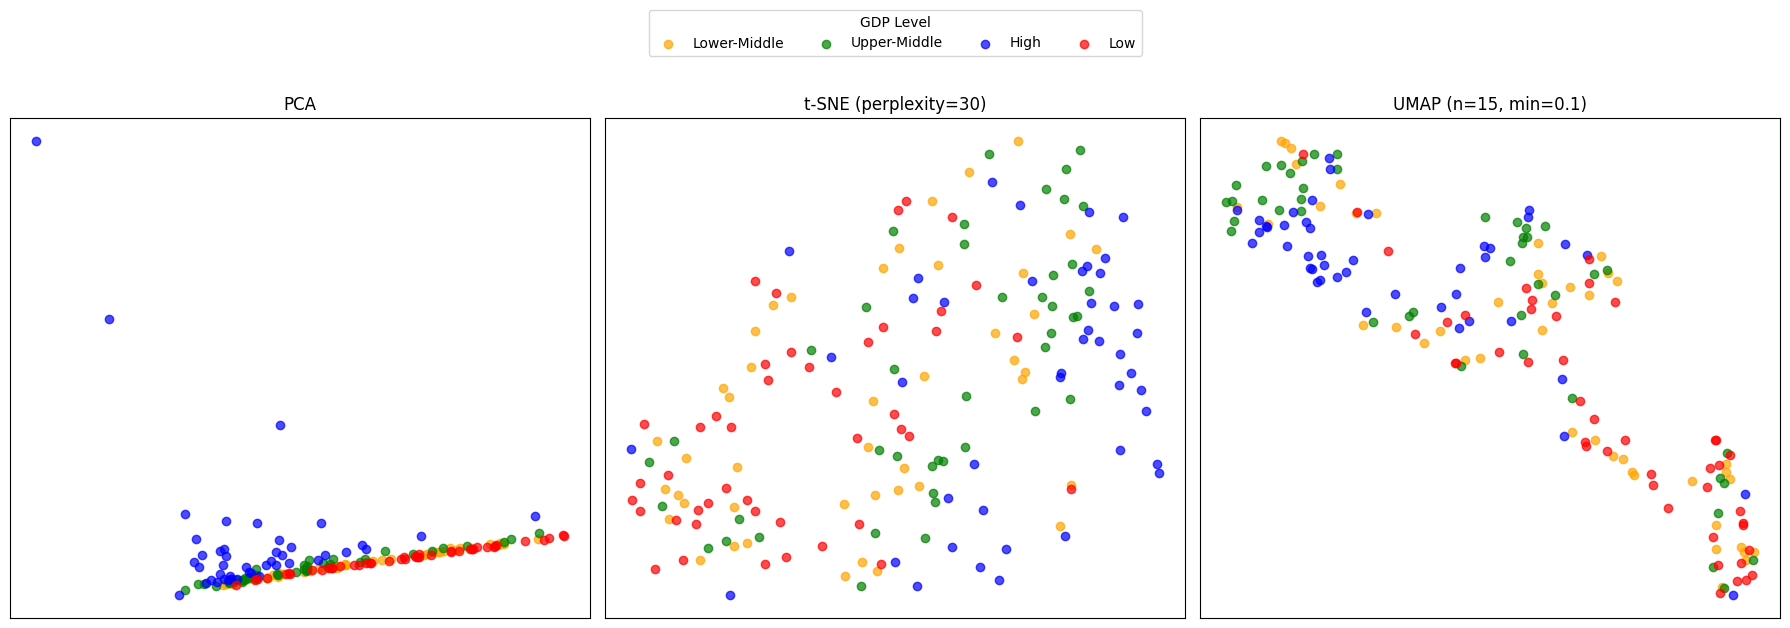

In [49]:
# COLORS (shared legend)
colors = {
    "Low": "red",
    "Lower-Middle": "orange",
    "Upper-Middle": "green",
    "High": "blue"
}

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    max_iter=1000
)
X_tsne = tsne.fit_transform(df_scaled)

# UMAP
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
X_umap = umap_model.fit_transform(df_scaled)

# PLOT
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

methods = [
    ("PCA", X_pca),
    ("t-SNE (perplexity=30)", X_tsne),
    ("UMAP (n=15, min=0.1)", X_umap)
]

for ax, (title, X) in zip(axes, methods):

    for level in gdp_q.unique():
        idx = gdp_q == level

        ax.scatter(
            X[idx, 0],
            X[idx, 1],
            color=colors[level],
            label=level,
            alpha=0.7
        )

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# SINGLE LEGEND (GLOBAL)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="GDP Level",
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.05)  # moves legend above plots
)

plt.tight_layout(rect=[0, 0, 1, 0.92])  # leaves space at top
plt.show()

In a paragraph, compare the three methods based on what you actually see in your plots. Cover: which method separates the development groups most clearly, which axes are meaningful and which are not, and which method you would trust most if you needed to apply it to new countries next year.

- In the plots, t-SNE shows the clearest separation between development groups, as countries form distinct clusters with minimal overlap compared to PCA and UMAP. PCA, however, has more interpretable axes, since its components are linear combinations of the original features and can be explained using feature loadings, unlike t-SNE and UMAP where the axes themselves have no direct meaning and only represent relative positioning. UMAP also produces visible clusters, but the separation is generally less distinct than t-SNE in this dataset. If I needed to apply the method to new countries in the future, I would trust UMAP more than PCA and t-SNE, because UMAP tends to preserve structure more consistently across datasets. t-SNE is useful for visualization, but it is not interpretable and PCA is more interpretable but for this dataset the clusters are so compressed that it forms a line-like shape.

A team of policy analysts wants to group countries based on their development indicators to help design foreign aid programs. They need something they can explain to non-technical managers, understand which indicators drive the groupings, and apply to new countries next year.

Write a recommendation for which method they should use. Your answer must cover all four points below. Use them as headers.

1. What method do you recommend and why?
2. What from your results supports this? Point to at least two specific things you found in Parts 2 or 3.
3. What are the limitations of your choice? Name at least two weaknesses and how the team should deal with them.
4. What are the other methods still good for? Even if you did not pick t-SNE or UMAP as the main method, explain where they still help.

Response:
- I would recommend using UMAP as the main method for grouping countries based on their GDP development levels. UMAP is the best overall choice because it produces clear and interpretable clusters that can be easily explained, while also remaining more interpretable and stable for applying to new countries in the future compared to t-SNE. It also provides a better balance between visualization and structure compared to PCA, which is more interpretable but does not separate development groups as clearly in the plots.

- This recommendation is supported by the results from the analysis. In the UMAP visualization (with n_neighbors = 15 and min_dist = 0.1), countries formed distinct and meaningful clusters that aligned well with the GDP development groups, making the separation easy to interpret visually. In contrast, t-SNE at perplexity = 30 also showed strong cluster separation, but the structure changed noticeably when different perplexity values were used, indicating that it is less stable and more sensitive to parameter choices. Additionally, the k-NN preservation results showed that UMAP have a more stable and consistent parameter selection as the difference in scores are not too significant, suggesting that UMAP preserves meaningful structure in the data while still simplifying it for visualization.

- However, UMAP also has limitations. One key limitation is that its axes are not directly interpretable, meaning we cannot clearly explain which specific indicators (such as GDP, life expectancy, or infant mortality) are responsible for the position of each country in the plot. Another limitation is that the results depend on hyperparameters like n_neighbors and min_dist, which can slightly change how clusters appear. To address this, we should test multiple parameter settings to ensure consistency and also combine UMAP with PCA to understand which indicators are driving the differences between countries.

- Although UMAP is the recommended main method, the other techniques still have important uses. PCA is valuable because it provides interpretable components and feature loadings, allowing analysts to clearly identify which development indicators contribute most to differences between countries. On the other hand, t-SNE is still useful for visualization because it produces very clear and visually strong clusters, which can help identify hidden patterns in the data. However, it is less suitable for use because it is unstable and does not generalize well to new data.

- Overall, PCA is best for interpretation, t-SNE is best for visualization, and UMAP is best for practical grouping and decision-making.

## References
- The code written above were aided by ChatGPT by OpenAI. Human revisions were supplied.
- Interpretations were purely written by humans.